
Successfully downloaded: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META']
Data shape: (251, 6)

Correlation matrix:
        AAPL   MSFT  GOOGL   AMZN   NVDA   META
AAPL   1.000  0.123  0.148  0.080  0.101  0.143
MSFT   0.123  1.000  0.150  0.387  0.256  0.166
GOOGL  0.148  0.150  1.000  0.534  0.239  0.299
AMZN   0.080  0.387  0.534  1.000  0.255  0.417
NVDA   0.101  0.256  0.239  0.255  1.000  0.301
META   0.143  0.166  0.299  0.417  0.301  1.000

Graph built with threshold |ρ| ≥ 0.3
Stocks : ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META']
Edges  : 4
  MSFT – AMZN : 0.387
  GOOGL – AMZN : 0.534
  AMZN – META : 0.417
  NVDA – META : 0.301


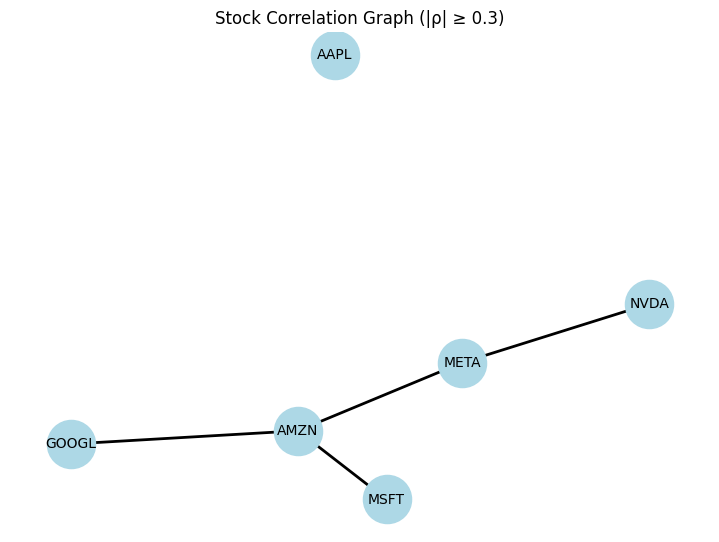


Classical baselines:
  Exact MaxCut      : 4
  Greedy            : 3

Cost Hamiltonian has 4 terms

Optimizing QAOA parameters (p=2) on simulator...
  Step  20 | <H> = -1.3238
  Step  40 | <H> = -1.4959
  Step  60 | <H> = -1.5024
  Step  80 | <H> = -1.5072
Optimized energy: -1.5072

Connecting to IBM Quantum...
Selected backend: ibm_fez

Transpiled circuit stats on ibm_fez:
  Depth            : 63
  2-qubit gates    : 16
  Total gate count : 126
  Op breakdown     : OrderedDict([('rz', 51), ('sx', 49), ('cz', 16), ('measure', 6), ('x', 4)])

Building noise model from backend calibration data...
Sampling on real hardware (1024 shots) with resilience_level=1...
Hardware sampling complete.

THREE-WAY RESULTS SUMMARY
Exact MaxCut value : 4
Greedy baseline     : 3

--- Noiseless Simulator ---
  Most probable cut     : 4
  Probability of optimal: 0.150
  Approximation ratio   : 1.000
    Cut  4 : 0.150
    Cut  3 : 0.355
    Cut  2 : 0.209
    Cut  1 : 0.279
    Cut  0 : 0.008

--- Noisy Si

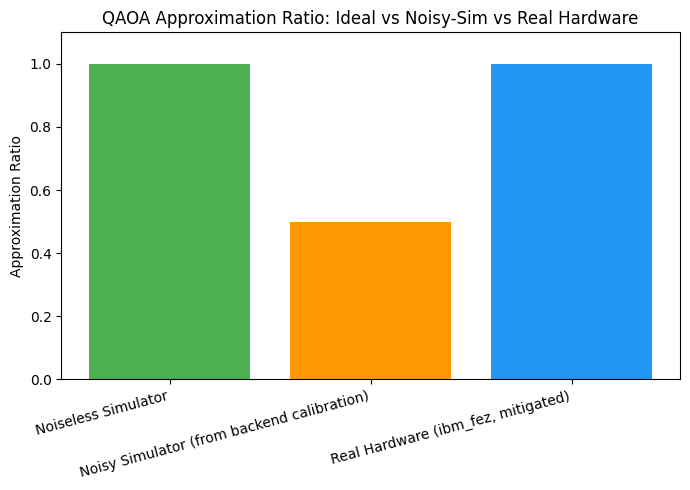

In [11]:
"""
QAOA MaxCut on Real IBM Quantum Hardware
========================================
Demonstration for CV / technical interviews.

Workflow:
1. Define a small graph
2. Build MaxCut cost Hamiltonian
3. Optimize QAOA parameters on classical simulator
4. Sample the optimized circuit on real IBM QPU
5. Compare against classical baselines
6. Analyze noise / success probability

Author: [Aditya Singh]
Date: 2026
"""

# Interpretation: MaxCut on correlation graph finds two groups of stocks
# with relatively low intra-group correlation (useful for diversification).

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
import pennylane as qml
from pennylane import numpy as pnp
from pennylane.optimize import AdamOptimizer
from qiskit_ibm_runtime import QiskitRuntimeService

# ============================================================
# 1. CONFIGURATION
# ============================================================
P_LAYERS = 2
SHOTS = 1024
N_OPT_STEPS = 80
SEED = 42
THRESHOLD = 0.30          # Adjust between 0.55–0.70 if needed

np.random.seed(SEED)

# ============================================================
# 2. REAL FINANCIAL STOCK CORRELATION GRAPH
# ============================================================
import yfinance as yf
import pandas as pd
import time

tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META"]

print("Downloading stock data (one by one for reliability)...")

data_frames = []
successful_tickers = []

for ticker in tickers:
    try:
        print(f"  Downloading {ticker}...", end=" ")
        df = yf.download(ticker, period="1y", auto_adjust=True, progress=False)
        
        if df.empty:
            print("FAILED (empty)")
            continue
            
        # Keep only Close price and rename column to ticker name
        close = df[["Close"]].copy()
        close.columns = [ticker]
        data_frames.append(close)
        successful_tickers.append(ticker)
        print("OK")
        
        time.sleep(1)   # small pause to avoid overloading Yahoo
        
    except Exception as e:
        print(f"FAILED ({e})")

if len(successful_tickers) < 4:
    raise ValueError("Too many download failures. Try again later or change tickers.")

# Combine all successful downloads
data = pd.concat(data_frames, axis=1).dropna()
tickers = successful_tickers          # update the list to only successful ones

print(f"\nSuccessfully downloaded: {tickers}")
print(f"Data shape: {data.shape}")

# Calculate returns and correlation
returns = data.pct_change().dropna()
corr_matrix = returns.corr()

print("\nCorrelation matrix:")
print(corr_matrix.round(3))

# Build the graph
G = nx.Graph()
G.add_nodes_from(range(len(tickers)))

edges = []
for i, j in combinations(range(len(tickers)), 2):
    corr = abs(corr_matrix.iloc[i, j])
    if corr >= THRESHOLD:
        G.add_edge(i, j, weight=corr)
        edges.append((i, j, corr))

N_NODES = len(tickers)

print(f"\nGraph built with threshold |ρ| ≥ {THRESHOLD}")
print(f"Stocks : {tickers}")
print(f"Edges  : {G.number_of_edges()}")

if G.number_of_edges() == 0:
    raise ValueError("No edges created. Lower the THRESHOLD (try 0.25–0.35).")

for i, j, w in edges:
    print(f"  {tickers[i]} – {tickers[j]} : {w:.3f}")

# Optional: draw the correlation graph
pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(7, 5))
nx.draw(G, pos, with_labels=True, labels={i: tickers[i] for i in range(len(tickers))},
        node_color="lightblue", node_size=1200, font_size=10, width=2)
plt.title(f"Stock Correlation Graph (|ρ| ≥ {THRESHOLD})")
plt.savefig("stock_correlation_graph.png", dpi=150, bbox_inches="tight")
plt.show()

# ============================================================
# 3. CLASSICAL BASELINES
# ============================================================
def maxcut_value(bitstring, graph, tickers=None):
    cut = 0
    for u, v in graph.edges():
        if bitstring[u] != bitstring[v]:
            cut += 1
    return cut

def exact_maxcut(graph):
    """Brute-force exact MaxCut (feasible for n ≤ 12)."""
    n = graph.number_of_nodes()
    best_cut = 0
    best_bitstring = None
    for bits in range(2**n):
        bitstring = [(bits >> i) & 1 for i in range(n)]
        cut = maxcut_value(bitstring, graph)
        if cut > best_cut:
            best_cut = cut
            best_bitstring = bitstring
    return best_cut, best_bitstring

def greedy_maxcut(graph):
    """Simple greedy baseline."""
    n = graph.number_of_nodes()
    assignment = [0] * n
    for i in range(n):
        # Try both assignments and keep the better one
        best_local = -1
        best_val = -1
        for val in [0, 1]:
            assignment[i] = val
            cut = maxcut_value(assignment, graph)
            if cut > best_val:
                best_val = cut
                best_local = val
        assignment[i] = best_local
    return maxcut_value(assignment, graph), assignment

exact_cut, exact_bits = exact_maxcut(G)
greedy_cut, greedy_bits = greedy_maxcut(G)

print(f"\nClassical baselines:")
print(f"  Exact MaxCut      : {exact_cut}")
print(f"  Greedy            : {greedy_cut}")

# ============================================================
# 4. QAOA COST HAMILTONIAN (MaxCut)
# ============================================================
def maxcut_hamiltonian(graph):
    """
    MaxCut cost Hamiltonian:
    H_C = 1/2 * sum_{(i,j) in E} (1 - Z_i Z_j)
    We drop the constant and use -1/2 Z_i Z_j so that
    minimizing <H> is equivalent to maximizing the cut.
    """
    coeffs = []
    ops = []
    for i, j in graph.edges():
        coeffs.append(-0.5)
        ops.append(qml.PauliZ(i) @ qml.PauliZ(j))
    return qml.Hamiltonian(coeffs, ops)

H_cost = maxcut_hamiltonian(G)
print(f"\nCost Hamiltonian has {len(H_cost.coeffs)} terms")

if len(H_cost.coeffs) == 0:
    raise ValueError("Hamiltonian is empty — graph has no edges.")

# ============================================================
# 5. QAOA CIRCUIT + OPTIMIZATION (SIMULATOR)
# ============================================================
dev_sim = qml.device("default.qubit", wires=N_NODES)

@qml.qnode(dev_sim)
def qaoa_cost(params):
    gammas = params[:P_LAYERS]
    betas  = params[P_LAYERS:]
    
    # Initial superposition
    for w in range(N_NODES):
        qml.Hadamard(wires=w)
    
    for layer in range(P_LAYERS):
        # Cost layer
        qml.ApproxTimeEvolution(H_cost, gammas[layer], 1)
        # Mixer layer (X rotations)
        for w in range(N_NODES):
            qml.RX(2 * betas[layer], wires=w)
    
    return qml.expval(H_cost)

# Optimize
opt = AdamOptimizer(stepsize=0.1)
params = pnp.random.uniform(0, np.pi, 2 * P_LAYERS, requires_grad=True)

print(f"\nOptimizing QAOA parameters (p={P_LAYERS}) on simulator...")
for step in range(N_OPT_STEPS):
    params = opt.step(qaoa_cost, params)
    if (step + 1) % 20 == 0:
        energy = float(qaoa_cost(params))
        print(f"  Step {step+1:3d} | <H> = {energy:.4f}")

final_energy = float(qaoa_cost(params))
print(f"Optimized energy: {final_energy:.4f}")

# ============================================================
# 6. HARDWARE EXECUTION (Qiskit Runtime Primitives + Mitigation)
# ============================================================
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import Parameter
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2, EstimatorV2
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

print("\nConnecting to IBM Quantum...")
service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=N_NODES)
print(f"Selected backend: {backend.name}")

# --- Build the QAOA circuit natively in Qiskit (not PennyLane) ---
def build_qaoa_circuit(graph, p_layers, gammas, betas):
    n = graph.number_of_nodes()
    qc = QuantumCircuit(n, n)
    qc.h(range(n))
    for layer in range(p_layers):
        for i, j in graph.edges():
            qc.cx(i, j)
            qc.rz(2 * gammas[layer], j)
            qc.cx(i, j)
        for w in range(n):
            qc.rx(2 * betas[layer], w)
    qc.measure(range(n), range(n))
    return qc

gammas_opt = [float(g) for g in params[:P_LAYERS]]
betas_opt  = [float(b) for b in params[P_LAYERS:]]

qc_logical = build_qaoa_circuit(G, P_LAYERS, gammas_opt, betas_opt)

# --- Transpile for the real backend, inspect the cost of mapping ---
qc_transpiled = transpile(qc_logical, backend=backend, optimization_level=3)

print(f"\nTranspiled circuit stats on {backend.name}:")
print(f"  Depth            : {qc_transpiled.depth()}")
op_counts = qc_transpiled.count_ops()
print(f"  2-qubit gates    : {op_counts.get('cz', 0) + op_counts.get('ecr', 0) + op_counts.get('cx', 0)}")
print(f"  Total gate count : {sum(op_counts.values())}")
print(f"  Op breakdown     : {op_counts}")

# ============================================================
# 6b. NOISY SIMULATOR BASELINE (isolates noise vs. algorithm)
# ============================================================
print("\nBuilding noise model from backend calibration data...")
noise_model = NoiseModel.from_backend(backend)
noisy_sim = AerSimulator(noise_model=noise_model)

qc_noisy_run = transpile(qc_logical, backend=noisy_sim, optimization_level=3)
noisy_result = noisy_sim.run(qc_noisy_run, shots=SHOTS).result()
noisy_counts = noisy_result.get_counts()

def counts_to_probs(counts, n_qubits, shots):
    probs = np.zeros(2**n_qubits)
    for bitstr, count in counts.items():
        # Qiskit bit order is reversed relative to our wire order
        idx = int(bitstr[::-1], 2)
        probs[idx] = count / shots
    return probs

noisy_probs = counts_to_probs(noisy_counts, N_NODES, SHOTS)

# ============================================================
# 6c. REAL HARDWARE RUN WITH ERROR MITIGATION (SamplerV2)
# ============================================================
print(f"Sampling on real hardware ({SHOTS} shots) with resilience_level=1...")
sampler = SamplerV2(mode=backend)
sampler.options.default_shots = SHOTS
# resilience isn't a Sampler option directly in all versions;
# for readout mitigation use dynamical decoupling + twirling instead:
sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = "XY4"
sampler.options.twirling.enable_gates = True
sampler.options.twirling.enable_measure = True

job = sampler.run([qc_transpiled])
result = job.result()
counts_hw = result[0].data.c.get_counts()

hw_probs = counts_to_probs(counts_hw, N_NODES, SHOTS)

print("Hardware sampling complete.")

# ============================================================
# 6d. TRUE NOISELESS SIMULATOR BASELINE
# ============================================================
from qiskit.quantum_info import Statevector

# Build the circuit WITHOUT measurement for exact statevector simulation
def build_qaoa_circuit_no_measure(graph, p_layers, gammas, betas):
    n = graph.number_of_nodes()
    qc = QuantumCircuit(n)
    qc.h(range(n))
    for layer in range(p_layers):
        for i, j in graph.edges():
            qc.cx(i, j)
            qc.rz(2 * gammas[layer], j)
            qc.cx(i, j)
        for w in range(n):
            qc.rx(2 * betas[layer], w)
    return qc

qc_ideal = build_qaoa_circuit_no_measure(G, P_LAYERS, gammas_opt, betas_opt)
ideal_state = Statevector.from_instruction(qc_ideal)
ideal_probs_raw = ideal_state.probabilities()

# Statevector ordering is little-endian by qubit index already matching
# our wire convention here (no measurement/classical-register reversal issue)
ideal_probs = ideal_probs_raw

# ============================================================
# 7. ANALYZE RESULTS — THREE-WAY COMPARISON
# ============================================================
def analyze(probs, label, graph, exact_cut, tickers, n_nodes):
    cut_counts = {}
    total_prob_optimal = 0.0
    for state in range(2**n_nodes):
        bitstring = [(state >> i) & 1 for i in range(n_nodes)]
        cut = maxcut_value(bitstring, graph)
        p = float(probs[state])
        cut_counts[cut] = cut_counts.get(cut, 0.0) + p
        if cut == exact_cut:
            total_prob_optimal += p

    best_state = int(np.argmax(probs))
    best_bits = [(best_state >> i) & 1 for i in range(n_nodes)]
    best_cut = maxcut_value(best_bits, graph)



    print(f"\n--- {label} ---")
    print(f"  Most probable cut     : {best_cut}")
    print(f"  Probability of optimal: {total_prob_optimal:.3f}")
    print(f"  Approximation ratio   : {best_cut / exact_cut:.3f}")
    for cut in sorted(cut_counts.keys(), reverse=True):
        print(f"    Cut {cut:2d} : {cut_counts[cut]:.3f}")
    return {"label": label, "best_cut": best_cut,
            "prob_optimal": total_prob_optimal,
            "approx_ratio": best_cut / exact_cut,
            "cut_counts": cut_counts}

print("\n" + "="*55)
print("THREE-WAY RESULTS SUMMARY")
print("="*55)
print(f"Exact MaxCut value : {exact_cut}")
print(f"Greedy baseline     : {greedy_cut}")

results_noiseless = analyze(ideal_probs, "Noiseless Simulator", G, exact_cut, tickers, N_NODES)
results_noisy      = analyze(noisy_probs, "Noisy Simulator (from backend calibration)", G, exact_cut, tickers, N_NODES)
results_hw         = analyze(hw_probs, f"Real Hardware ({backend.name}, mitigated)", G, exact_cut, tickers, N_NODES)

# ============================================================
# 7b. EXPECTED APPROXIMATION RATIO (probability-weighted, more robust)
# ============================================================
def expected_approx_ratio(probs, graph, exact_cut, n_nodes):
    expected_cut = sum(
        float(probs[state]) * maxcut_value([(state >> i) & 1 for i in range(n_nodes)], graph)
        for state in range(2**n_nodes)
    )
    return expected_cut / exact_cut

print("\nExpected approximation ratio (probability-weighted, more robust):")
print(f"  Noiseless : {expected_approx_ratio(ideal_probs, G, exact_cut, N_NODES):.3f}")
print(f"  Noisy Sim : {expected_approx_ratio(noisy_probs, G, exact_cut, N_NODES):.3f}")
print(f"  Hardware  : {expected_approx_ratio(hw_probs, G, exact_cut, N_NODES):.3f}")

# --- Plot approximation ratio comparison ---
labels = [results_noiseless["label"], results_noisy["label"], results_hw["label"]]
ratios = [results_noiseless["approx_ratio"], results_noisy["approx_ratio"], results_hw["approx_ratio"]]
...

# --- Plot approximation ratio comparison ---
labels = [results_noiseless["label"], results_noisy["label"], results_hw["label"]]
ratios = [results_noiseless["approx_ratio"], results_noisy["approx_ratio"], results_hw["approx_ratio"]]

plt.figure(figsize=(7, 5))
plt.bar(labels, ratios, color=["#4CAF50", "#FF9800", "#2196F3"])
plt.ylabel("Approximation Ratio")
plt.title("QAOA Approximation Ratio: Ideal vs Noisy-Sim vs Real Hardware")
plt.ylim(0, 1.1)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("approx_ratio_comparison.png", dpi=150, bbox_inches="tight")
plt.show()



P-SWEEP: p = 1
  Optimized energy (p=1, best of 5 restarts): -1.0581
  Noiseless expected ratio : 0.665
  Noisy-sim expected ratio : 0.564
  Transpiled depth (p=1) : 37, 2q gates: 8
  Hardware expected ratio  : 0.564

P-SWEEP: p = 2
  Optimized energy (p=2, best of 5 restarts): -1.5078
  Noiseless expected ratio : 0.596
  Noisy-sim expected ratio : 0.541
  Transpiled depth (p=2) : 61, 2q gates: 16
  Hardware expected ratio  : 0.536

P-SWEEP: p = 3
  Optimized energy (p=3, best of 5 restarts): -1.5606
  Noiseless expected ratio : 0.624
  Noisy-sim expected ratio : 0.554
  Transpiled depth (p=3) : 80, 2q gates: 24
  Hardware expected ratio  : 0.550

P-SWEEP: p = 4
  Optimized energy (p=4, best of 5 restarts): -1.8320
  Noiseless expected ratio : 0.705
  Noisy-sim expected ratio : 0.573
  Transpiled depth (p=4) : 104, 2q gates: 32
  Hardware expected ratio  : 0.554


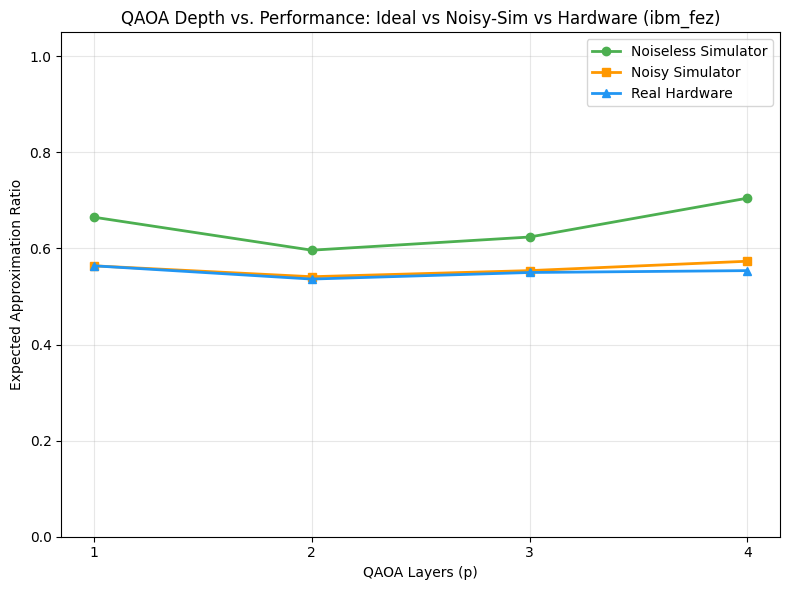


P-sweep summary:
  p=1: noiseless=0.665, noisy_sim=0.564, hardware=0.564
  p=2: noiseless=0.596, noisy_sim=0.541, hardware=0.536
  p=3: noiseless=0.624, noisy_sim=0.554, hardware=0.550
  p=4: noiseless=0.705, noisy_sim=0.573, hardware=0.554


In [13]:
# ============================================================
# 9. P-SWEEP: DOES DEPTH HELP OR HURT UNDER NOISE?
# (with multi-restart classical optimization to avoid bad local minima)
# ============================================================
P_VALUES = [1, 2, 3, 4]
N_RESTARTS = 5
sweep_results = {
    "p": [], "noiseless": [], "noisy_sim": [], "hardware": []
}

def build_qaoa_circuit_qiskit(graph, p_layers, gammas, betas, n_nodes, measure=True):
    qc = QuantumCircuit(n_nodes, n_nodes) if measure else QuantumCircuit(n_nodes)
    qc.h(range(n_nodes))
    for layer in range(p_layers):
        for i, j in graph.edges():
            qc.cx(i, j)
            qc.rz(2 * gammas[layer], j)
            qc.cx(i, j)
        for w in range(n_nodes):
            qc.rx(2 * betas[layer], w)
    if measure:
        qc.measure(range(n_nodes), range(n_nodes))
    return qc

for p in P_VALUES:
    print(f"\n{'='*55}")
    print(f"P-SWEEP: p = {p}")
    print(f"{'='*55}")

    dev_sim_p = qml.device("default.qubit", wires=N_NODES)

    @qml.qnode(dev_sim_p)
    def qaoa_cost_p(params, p_layers=p):
        gammas = params[:p_layers]
        betas = params[p_layers:]
        for w in range(N_NODES):
            qml.Hadamard(wires=w)
        for layer in range(p_layers):
            qml.ApproxTimeEvolution(H_cost, gammas[layer], 1)
            for w in range(N_NODES):
                qml.RX(2 * betas[layer], wires=w)
        return qml.expval(H_cost)

    # --- Multi-restart optimization (classical only, no QPU cost) ---
    best_energy_p = None
    best_params_p = None
    for restart in range(N_RESTARTS):
        params_try = pnp.random.uniform(0, np.pi, 2 * p, requires_grad=True)
        opt_try = AdamOptimizer(stepsize=0.1)
        for step in range(N_OPT_STEPS):
            params_try = opt_try.step(lambda x: qaoa_cost_p(x, p), params_try)
        energy_try = float(qaoa_cost_p(params_try, p))
        if best_energy_p is None or energy_try < best_energy_p:
            best_energy_p = energy_try
            best_params_p = params_try

    params_p = best_params_p
    final_energy_p = best_energy_p
    print(f"  Optimized energy (p={p}, best of {N_RESTARTS} restarts): {final_energy_p:.4f}")

    gammas_p = [float(g) for g in params_p[:p]]
    betas_p  = [float(b) for b in params_p[p:]]

    # --- Noiseless statevector ---
    qc_ideal_p = build_qaoa_circuit_qiskit(G, p, gammas_p, betas_p, N_NODES, measure=False)
    ideal_probs_p = Statevector.from_instruction(qc_ideal_p).probabilities()
    ratio_ideal = expected_approx_ratio(ideal_probs_p, G, exact_cut, N_NODES)
    print(f"  Noiseless expected ratio : {ratio_ideal:.3f}")

    # --- Noisy simulator ---
    qc_meas_p = build_qaoa_circuit_qiskit(G, p, gammas_p, betas_p, N_NODES, measure=True)
    qc_noisy_p = transpile(qc_meas_p, backend=noisy_sim, optimization_level=3)
    noisy_result_p = noisy_sim.run(qc_noisy_p, shots=SHOTS).result()
    noisy_probs_p = counts_to_probs(noisy_result_p.get_counts(), N_NODES, SHOTS)
    ratio_noisy = expected_approx_ratio(noisy_probs_p, G, exact_cut, N_NODES)
    print(f"  Noisy-sim expected ratio : {ratio_noisy:.3f}")

    # --- Real hardware ---
    qc_hw_p = transpile(qc_meas_p, backend=backend, optimization_level=3)
    print(f"  Transpiled depth (p={p}) : {qc_hw_p.depth()}, "
          f"2q gates: {qc_hw_p.count_ops().get('cz', 0)}")

    job_p = sampler.run([qc_hw_p])
    result_p = job_p.result()
    counts_hw_p = result_p[0].data.c.get_counts()
    hw_probs_p = counts_to_probs(counts_hw_p, N_NODES, SHOTS)
    ratio_hw = expected_approx_ratio(hw_probs_p, G, exact_cut, N_NODES)
    print(f"  Hardware expected ratio  : {ratio_hw:.3f}")

    sweep_results["p"].append(p)
    sweep_results["noiseless"].append(ratio_ideal)
    sweep_results["noisy_sim"].append(ratio_noisy)
    sweep_results["hardware"].append(ratio_hw)

# ============================================================
# 9b. PLOT: APPROXIMATION RATIO VS CIRCUIT DEPTH (p)
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(sweep_results["p"], sweep_results["noiseless"], "o-", label="Noiseless Simulator", color="#4CAF50", linewidth=2)
plt.plot(sweep_results["p"], sweep_results["noisy_sim"], "s-", label="Noisy Simulator", color="#FF9800", linewidth=2)
plt.plot(sweep_results["p"], sweep_results["hardware"], "^-", label="Real Hardware", color="#2196F3", linewidth=2)
plt.xlabel("QAOA Layers (p)")
plt.ylabel("Expected Approximation Ratio")
plt.title(f"QAOA Depth vs. Performance: Ideal vs Noisy-Sim vs Hardware ({backend.name})")
plt.xticks(sweep_results["p"])
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("qaoa_p_sweep.png", dpi=200, bbox_inches="tight")
plt.show()

print("\nP-sweep summary:")
for i, p in enumerate(sweep_results["p"]):
    print(f"  p={p}: noiseless={sweep_results['noiseless'][i]:.3f}, "
          f"noisy_sim={sweep_results['noisy_sim'][i]:.3f}, "
          f"hardware={sweep_results['hardware'][i]:.3f}")

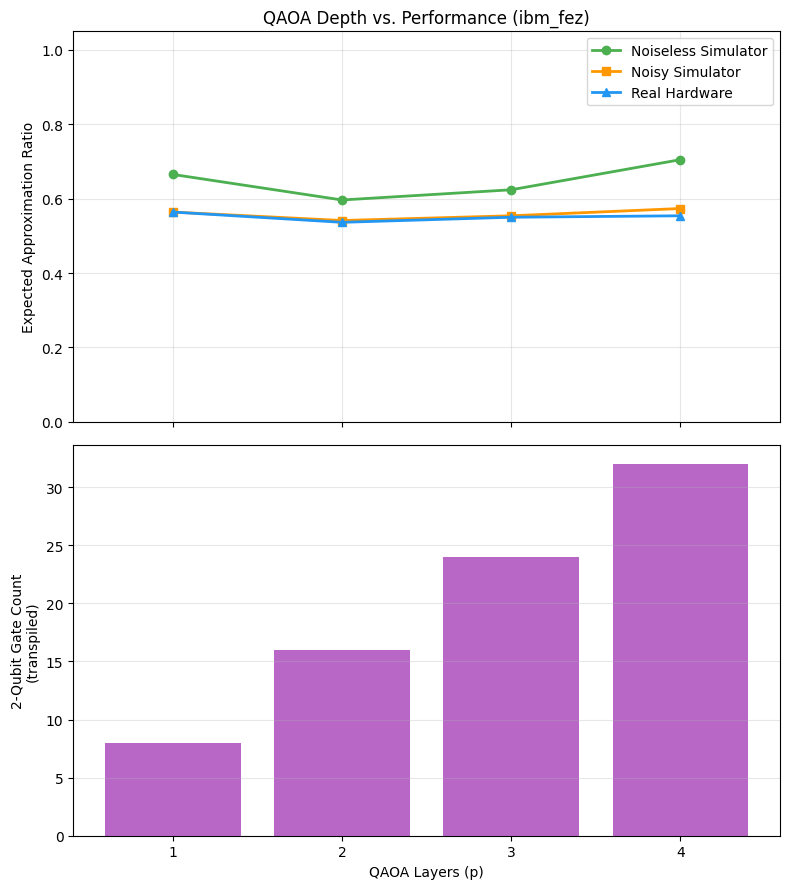

In [14]:
# ============================================================
# 9c. TWO-PANEL: APPROX RATIO + GATE COUNT VS DEPTH
# ============================================================
gate_counts = [8, 16, 24, 32]  # from your printed p-sweep output

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9), sharex=True)

ax1.plot(sweep_results["p"], sweep_results["noiseless"], "o-", label="Noiseless Simulator", color="#4CAF50", linewidth=2)
ax1.plot(sweep_results["p"], sweep_results["noisy_sim"], "s-", label="Noisy Simulator", color="#FF9800", linewidth=2)
ax1.plot(sweep_results["p"], sweep_results["hardware"], "^-", label="Real Hardware", color="#2196F3", linewidth=2)
ax1.set_ylabel("Expected Approximation Ratio")
ax1.set_title(f"QAOA Depth vs. Performance ({backend.name})")
ax1.set_ylim(0, 1.05)
ax1.legend()
ax1.grid(alpha=0.3)

ax2.bar(sweep_results["p"], gate_counts, color="#9C27B0", alpha=0.7)
ax2.set_xlabel("QAOA Layers (p)")
ax2.set_ylabel("2-Qubit Gate Count\n(transpiled)")
ax2.set_xticks(sweep_results["p"])
ax2.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("qaoa_p_sweep_with_gates.png", dpi=200, bbox_inches="tight")
plt.show()